CPS 最终模型

In [2]:
import numpy as np
import pandas as pd

# =========================================================
# CPS MODEL: Awareness-triggered Event Migration + SIR
# 核心函数部分（完全不变，省略中间注释以节省篇幅）
# =========================================================

def compute_epsilon(states, alpha, epsilon0):
    p_A = states[:, 1] + states[:, 2] + states[:, 4]
    return np.where(p_A > alpha, epsilon0, 0.0)

def compute_effective_awareness(n, states, g_i, R):
    N, M = R.shape
    p_A = states[:, 1] + states[:, 2] + states[:, 4]
    tilde_p_A = np.zeros(M)
    for j in range(M):
        numerator, denominator = 0.0, 0.0
        for i in range(N):
            flow = n[i] * g_i[i] * R[i, j]
            numerator += flow * p_A[i]
            denominator += flow
        tilde_p_A[j] = numerator / denominator if denominator > 0 else 0
    return tilde_p_A

def compute_awareness_conversion(R, lambda1, tilde_p_A):
    N, M = R.shape
    r = np.zeros(N)
    for i in range(N):
        prod = 1.0
        for j in range(M):
            prod *= (1 - lambda1 * R[i, j] * tilde_p_A[j])
        r[i] = 1 - prod
    return r

def compute_infection_residence(n, states, g_i, beta_U, beta_A):
    n_remain = n * (1 - g_i)
    AI = states[:, 2]
    N_U = 1 - np.power(1 - beta_U * AI, n_remain)
    N_A = 1 - np.power(1 - beta_A * AI, n_remain)
    return N_U, N_A

def compute_infection_transit(n, states, g_i, R, beta_U, beta_A):
    N, M = R.shape
    AI = states[:, 2]
    M_U = np.zeros(M)
    M_A = np.zeros(M)
    for j in range(M):
        prod_U, prod_A = 1.0, 1.0
        for k in range(N):
            n_to_j = n[k] * g_i[k] * R[k, j]
            prod_U *= np.power(1 - beta_U * AI[k], n_to_j)
            prod_A *= np.power(1 - beta_A * AI[k], n_to_j)
        M_U[j] = 1 - prod_U
        M_A[j] = 1 - prod_A
    return M_U, M_A

def compute_overall_infection(g_i, R, N_U, N_A, M_U, M_A):
    Q_U = (1 - g_i) * N_U + g_i * np.dot(R, M_U)
    Q_A = (1 - g_i) * N_A + g_i * np.dot(R, M_A)
    return Q_U, Q_A

def update_states(states, r, Q_U, Q_A, mu1, mu2):
    US, AS, AI, UR, AR = states.T
    new_US = US * (1 - r) * (1 - Q_U) + AS * mu1 * (1 - Q_U)
    new_AS = AS * (1 - mu1) * (1 - Q_A) + US * r * (1 - Q_A)
    new_AI = (AI * (1 - mu2)
              + AS * (1 - mu1) * Q_A
              + AS * mu1 * Q_U
              + US * (1 - r) * Q_U
              + US * r * Q_A)
    new_UR = AI * mu1 * mu2 + AR * mu1 + UR * (1 - r)
    new_AR = AR * (1 - mu1) + AI * (1 - mu1) * mu2 + UR * r
    new_states = np.vstack([new_US, new_AS, new_AI, new_UR, new_AR]).T
    new_states /= new_states.sum(axis=1, keepdims=True)
    return new_states

def update_population(n, states, g_i, epsilon, R, T):
    N, M = R.shape
    X = states * n[:, None]
    X_remain = X - (X.T * (g_i * epsilon)).T
    m_X = np.zeros((M, 5))
    for j in range(M):
        for i in range(N):
            flow = X[i] * g_i[i] * epsilon[i] * R[i, j]
            m_X[j] += flow
    flow_return_X = np.zeros((N, 5))
    for j in range(M):
        for i in range(N):
            flow_return_X[i] += m_X[j] * T[i, j]
    X_new = X_remain + flow_return_X
    n_new = np.sum(X_new, axis=1)
    states_new = X_new / n_new[:, None]
    return n_new, states_new

def main_simulation(Time, N, M, params):
    lambda1 = params["lambda1"]
    mu1 = params["mu1"]
    mu2 = params["mu2"]
    beta_U = params["beta_U"]
    beta_A = params["beta_A"]
    g = params["g"]
    theta = params["theta"]
    epsilon0 = params["epsilon0"]
    alpha = params["alpha"]

    g_i = np.full(N, theta * g)
    n = np.full(N, 200.0)

    states = np.zeros((N, 5))
    states[:, 0] = 0.99
    states[:, 2] = 0.01

    w = np.random.rand(N, M)
    Rmat = w / w.sum(axis=1, keepdims=True)
    Tmat = w / w.sum(axis=0, keepdims=True)

    history = np.zeros((Time, 5))

    for t in range(Time):
        global_state = np.sum(states * n[:, None], axis=0) / np.sum(n)
        history[t] = global_state

        epsilon = compute_epsilon(states, alpha, epsilon0)
        n_new, states_new = update_population(n, states, g_i, epsilon, Rmat, Tmat)
        tilde_p_A = compute_effective_awareness(n_new, states_new, g_i, Rmat)
        r = compute_awareness_conversion(Rmat, lambda1, tilde_p_A)
        N_U, N_A = compute_infection_residence(n_new, states_new, g_i, beta_U, beta_A)
        M_U, M_A = compute_infection_transit(n_new, states_new, g_i, Rmat, beta_U, beta_A)
        Q_U, Q_A = compute_overall_infection(g_i, Rmat, N_U, N_A, M_U, M_A)
        states = update_states(states_new, r, Q_U, Q_A, mu1, mu2)
        n = n_new

    return history

# =========================================================
# 重复实验主程序（200次，保存均值，无绘图）
# =========================================================
if __name__ == "__main__":
    Time = 150
    N = 15
    M = 5
    num_simulations = 20   # 重复实验次数

    params = {
        "lambda1": 0.2,
        "mu1": 0.15,
        "mu2": 0.1,
        "beta_U": 0.003,
        "beta_A": 0.0015,
        "g": 0.2,
        "epsilon0": 0.5,
        "alpha": 0.5,
        "theta": 1.0
    }

    # 累加所有仿真的历史
    total_history = np.zeros((Time, 5))

    for sim in range(num_simulations):
        history = main_simulation(Time, N, M, params)
        total_history += history
        # if (sim + 1) % 20 == 0:
        #     print(f"已完成 {sim + 1} / {num_simulations} 次仿真")

    # 计算均值
    mean_history = total_history / num_simulations

    # 保存均值CSV
    df = pd.DataFrame(mean_history, columns=["US", "AS", "AI", "UR", "AR"])
    df.to_csv("CPS_MMCA_mean.csv", index=False)

    print(f"CPS 模型 {num_simulations} 次重复实验完成，均值结果已保存。")
    print(df.head())

CPS 模型 20 次重复实验完成，均值结果已保存。
         US        AS        AI        UR        AR
0  0.990000  0.000000  0.010000  0.000000  0.000000
1  0.983512  0.001974  0.013514  0.000150  0.000850
2  0.974554  0.004873  0.018222  0.000480  0.001872
3  0.962371  0.008962  0.024493  0.001031  0.003142
4  0.946030  0.014561  0.032786  0.001863  0.004760


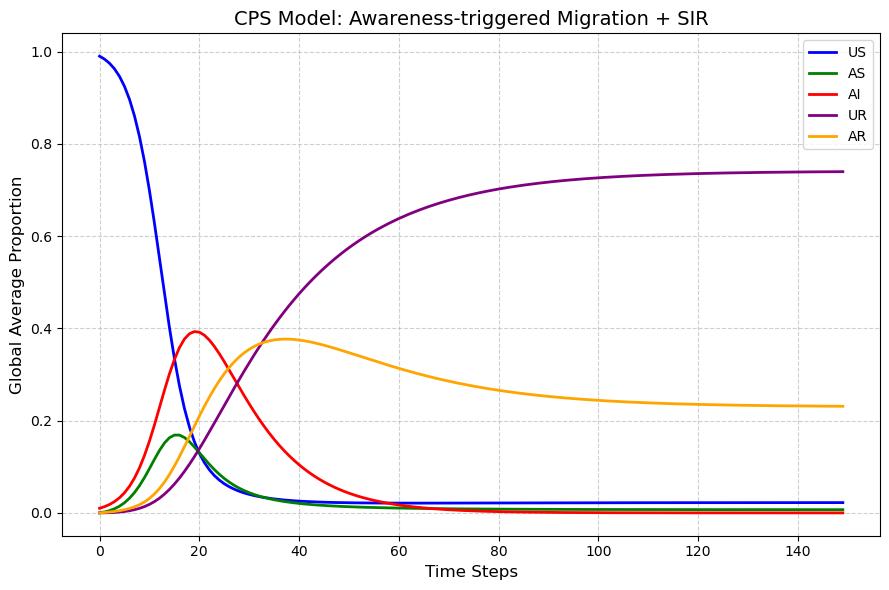

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

# ============================================
# 1. 读取 CPS 模型的输出 CSV 文件
# ============================================
file_name = "CPS_MMCA_mean.csv"          # 请确保文件在当前目录
df = pd.read_csv(file_name)

# ============================================
# 2. 设置颜色映射（与模板完全一致）
# ============================================
state_colors = {
    'US': 'blue',
    'AS': 'green',
    'AI': 'red',
    'UR': 'purple',
    'AR': 'orange'
}
state_labels = ['US', 'AS', 'AI', 'UR', 'AR']   # 必须与 df 列顺序一致

# ============================================
# 3. 创建画布并绘制各状态曲线
# ============================================
plt.figure(figsize=(9, 6))

for i, label in enumerate(state_labels):
    plt.plot(
        df.index,                 # 时间步（0 ~ Time-1）
        df[label],               # 该状态的全局平均比例
        label=label,
        color=state_colors[label],
        linewidth=2
    )

# ============================================
# 4. 图表装饰（模板风格）
# ============================================
plt.xlabel('Time Steps', fontsize=12)
plt.ylabel('Global Average Proportion', fontsize=12)
plt.title('CPS Model: Awareness-triggered Migration + SIR', fontsize=14)
plt.legend(fontsize=10, loc='upper right')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()

# 保存图片（可选）
# plt.savefig('CPS_MMCA_single_run.png', dpi=300, bbox_inches='tight')
plt.show()

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

# ============================================
# 1. 读取 CPS 模型的输出 CSV 文件
# ============================================
file_name = "CPS_MMCA_results.csv"          # 请确保文件在当前目录
df = pd.read_csv(file_name)

# ============================================
# 2. 计算总意识比例 A = AS + AI + AR
# ============================================
df['A'] = df['AS'] + df['AI'] + df['AR']

# ============================================
# 3. 创建画布并绘制 A 状态曲线
# ============================================
plt.figure(figsize=(9, 6))

plt.plot(
    df.index,                 # 时间步
    df['A'],                 # 总意识比例
    label='Aware (AS+AI+AR)',
    color='black',           # 可选用黑色，突出显示
    linewidth=2.5
)

# ============================================
# 4. 图表装饰（模板风格）
# ============================================
plt.xlabel('Time Steps', fontsize=12)
plt.ylabel('Global Average Proportion', fontsize=12)
plt.title('CPS Model: Awareness Dynamics (AS+AI+AR)', fontsize=14)
plt.legend(fontsize=11, loc='upper right')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()

# 保存图片（可选）
plt.savefig('CPS_Awareness_curve.png', dpi=300, bbox_inches='tight')
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: 'CPS_MMCA_results.csv'